# 💰 Loan Payment Simulator
### Phase 2 Project | FinTech Roadmap
A complete loan amortization simulator built with Python, NumPy, Pandas and Matplotlib.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2. Loan Inputs

In [2]:
principal = 200000.0       # Loan Amount (₹)
annual_rate = 8.5          # Annual Interest Rate (%)
tenure = 24.0              # Loan Tenure (months)

print(f"Loan Amount     : ₹{principal:,.2f}")
print(f"Annual Rate     : {annual_rate}%")
print(f"Tenure          : {int(tenure)} months ({int(tenure)//12} years {int(tenure)%12} months)")

Loan Amount     : ₹200,000.00
Annual Rate     : 8.5%
Tenure          : 24 months (2 years 0 months)


## 3. EMI Calculation

In [3]:
rate = annual_rate / (12 * 100)
common_factor = pow((1 + rate), tenure)
emi = principal * rate * (common_factor / (common_factor - 1))

total_payment = emi * tenure
total_interest = total_payment - principal

print(f"Monthly EMI         : ₹{emi:,.2f}")
print(f"Total Amount Paid   : ₹{total_payment:,.2f}")
print(f"Total Interest Paid : ₹{total_interest:,.2f}")

Monthly EMI         : ₹9,091.13
Total Amount Paid   : ₹218,187.24
Total Interest Paid : ₹18,187.24


## 4. Amortization Schedule

In [4]:
balance = principal
records = []

for i in range(1, int(tenure) + 1):
    monthly_interest = balance * rate
    monthly_principal = emi - monthly_interest
    opening_balance = balance
    balance = opening_balance - monthly_principal
    if balance < 0:
        balance = 0

    records.append({
        'Month'        : i,
        'Opening Bal'  : round(opening_balance, 2),
        'EMI'          : round(emi, 2),
        'Interest'     : round(monthly_interest, 2),
        'Principal'    : round(monthly_principal, 2),
        'Closing Bal'  : round(balance, 2)
    })

df = pd.DataFrame(records)
print(df.to_string(index=False))

 Month  Opening Bal     EMI  Interest  Principal  Closing Bal
     1    200000.00 9091.13   1416.67    7674.47    192325.53
     2    192325.53 9091.13   1362.31    7728.83    184596.70
     3    184596.70 9091.13   1307.56    7783.57    176813.13
     4    176813.13 9091.13   1252.43    7838.71    168974.42
     5    168974.42 9091.13   1196.90    7894.23    161080.19
     6    161080.19 9091.13   1140.98    7950.15    153130.04
     7    153130.04 9091.13   1084.67    8006.46    145123.57
     8    145123.57 9091.13   1027.96    8063.18    137060.40
     9    137060.40 9091.13    970.84    8120.29    128940.11
    10    128940.11 9091.13    913.33    8177.81    120762.30
    11    120762.30 9091.13    855.40    8235.74    112526.56
    12    112526.56 9091.13    797.06    8294.07    104232.49
    13    104232.49 9091.13    738.31    8352.82     95879.67
    14     95879.67 9091.13    679.15    8411.99     87467.68
    15     87467.68 9091.13    619.56    8471.57     78996.11
    16  

## 5. Summary Statistics

In [5]:
print("--- Loan Summary ---")
print(f"Average Monthly Interest  : ₹{df['Interest'].mean():,.2f}")
print(f"Average Monthly Principal : ₹{df['Principal'].mean():,.2f}")
print(f"Max Interest in a Month   : ₹{df['Interest'].max():,.2f} (Month {df['Interest'].idxmax()+1})")
print(f"Min Interest in a Month   : ₹{df['Interest'].min():,.2f} (Month {df['Interest'].idxmin()+1})")
print(f"75th Percentile Principal : ₹{np.percentile(df['Principal'], 75):,.2f}")

--- Loan Summary ---
Average Monthly Interest  : ₹757.80
Average Monthly Principal : ₹8,333.33
Max Interest in a Month   : ₹1,416.67 (Month 1)
Min Interest in a Month   : ₹63.94 (Month 24)
75th Percentile Principal : ₹8,668.19


## 6. Visualizations

### 6.1 Principal vs Interest Per Month

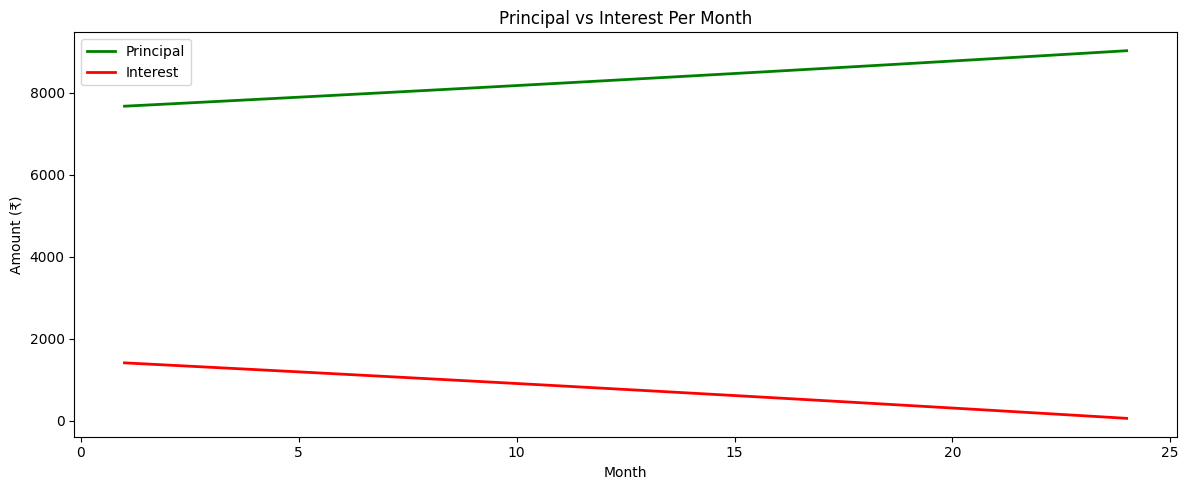

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df['Month'], df['Principal'], label='Principal', color='green', linewidth=2)
plt.plot(df['Month'], df['Interest'], label='Interest', color='red', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Amount (₹)')
plt.title('Principal vs Interest Per Month')
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Loan Balance Over Time

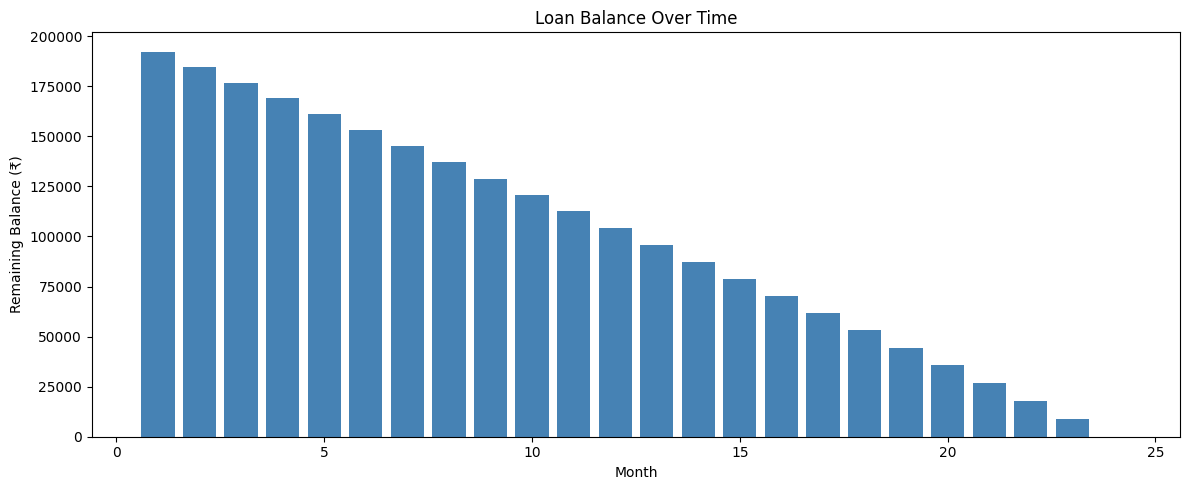

In [7]:
plt.figure(figsize=(12, 5))
plt.bar(df['Month'], df['Closing Bal'], color='steelblue')
plt.xlabel('Month')
plt.ylabel('Remaining Balance (₹)')
plt.title('Loan Balance Over Time')
plt.tight_layout()
plt.show()

### 6.3 Principal vs Total Interest Split

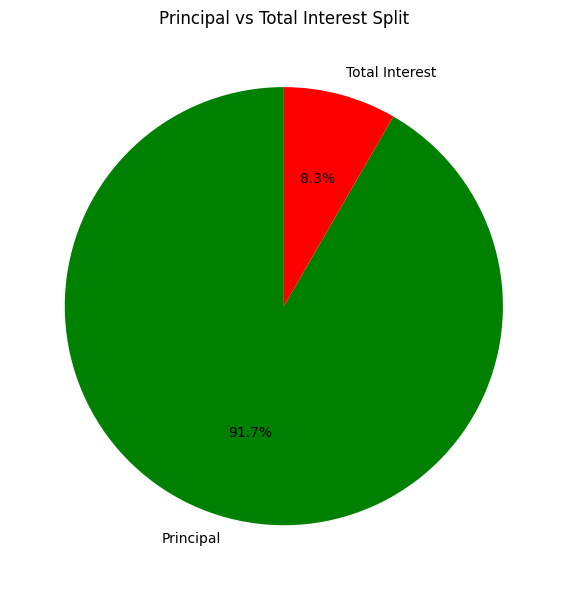

In [8]:
plt.figure(figsize=(6, 6))
plt.pie(
    [principal, total_interest],
    labels=['Principal', 'Total Interest'],
    autopct='%1.1f%%',
    colors=['green', 'red'],
    startangle=90
)
plt.title('Principal vs Total Interest Split')
plt.tight_layout()
plt.show()

## 7. Export Amortization Schedule

In [9]:
df.to_csv('loan_amortization_schedule.csv', index=False)
print("Amortization schedule exported to loan_amortization_schedule.csv")

Amortization schedule exported to loan_amortization_schedule.csv


## 8. Key Insights

In [10]:
print("--- Key Insights ---")
print(f"1. Monthly EMI                : ₹{emi:,.2f}")
print(f"2. Total Interest Paid        : ₹{total_interest:,.2f}")
print(f"3. Interest % of Total Payment: {(total_interest/total_payment)*100:.1f}%")
print(f"4. Highest Interest Month     : Month {df['Interest'].idxmax()+1}")
print(f"5. Loan Fully Paid By Month   : {int(tenure)}")

--- Key Insights ---
1. Monthly EMI                : ₹9,091.13
2. Total Interest Paid        : ₹18,187.24
3. Interest % of Total Payment: 8.3%
4. Highest Interest Month     : Month 1
5. Loan Fully Paid By Month   : 24
